# Assignment 1 — Making Sense of Northgate through Visualization
**INFO 4670 · Data Analysis and Knowledge Discovery**  ·  **Due: Sunday, 11:59 PM**

**Name:** MARK CHECHOTT    **Date:** 9/5/26

**The situation.** The Provost's question stands: *which students are struggling, and can we see it earlier?* This week you answer it the way analysts do — not by reading rows, but by drawing the data. Every chart below is built by **adapting code from the Guided notebook**; the intellectual work is choosing the right chart and reading it honestly.

**For every chart you make, you must:**
1. **Choose** the chart type that fits the variable(s) and the question.
2. **Build** it in Colab from the Northgate files.
3. **Label** it fully — title, axis labels, and units/legend. *An unlabeled chart is an unfinished chart.*
4. **Write a STAR story** underneath it — Scope · Track · Articulate · Respond (defined on the Concepts deck).

**How to work:** run Setup and Load first. Then, for each question, copy the closest cell from the Guided notebook into the empty cell, adapt it, and fill in the STAR cell below it.

**Submit:** push this notebook to GitHub and submit the **GitHub link** in Canvas. (See the setup doc: *Colab_GitHub_Setup_INFO4670_Fall2026*.)

## Setup — run this first (you don't need to change it)

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Northgate house style (optional, but keeps your charts consistent)
NAVY = "#22303A"
RUST = "#C0562F"
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"]   = (8, 5)
plt.rcParams["axes.titlesize"]   = 13
plt.rcParams["axes.titleweight"] = "bold"

## Load the data — run this, then look before you plot

In [18]:
# STEP 1 — get the data into this notebook. Pick ONE option, then run.

DATA_DIR = "."   # OPTION 2 (default) · drag the 3 CSVs into the file panel on the left

# OPTION 1 · read from Google Drive — uncomment and edit the path:
# from google.colab import drive
# drive.mount("/content/drive")
# DATA_DIR = "/content/drive/MyDrive/.../Data"

import os
students = pd.read_csv(os.path.join(DATA_DIR, "student_records.csv"))
weekly   = pd.read_csv(os.path.join(DATA_DIR, "weekly_activity.csv"))
courses = pd.read_csv(os.path.join(DATA_DIR, "course_enrollments.csv"))

students.head()

,student_id,major,age,housing,commute_miles,work_hours_per_week,advisor_meetings,credits_attempted,final_gpa,study_hours_reported,enrollment_date,dropped_out
0,NU-101508,Data Science,27,Off-Campus,7.6,15,1,81,1.86,NaN,2023-09-13,1
1,NU-102438,Learning Technologies,25,With Family,14.3,35,1,100,2.06,9.5,2023-10-19,0
2,NU-102385,Learning Technologies,26,With Family,3.4,18,9,77,3.41,19.1,11/16/2022,0
3,NU-100767,Cyber Security,22,On-Campus,23.7,40,1,65,1.73,8.1,2024-05-03,0
4,NU-106054,Information Technology,21,Off-Campus,2.3,20,4,59,2.37,6.6,10/24/2022,0


In [3]:
# how many rows, which columns, what types?
students.info()

<class 'pandas.DataFrame'>
RangeIndex: 2027 entries, 0 to 2026
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            2027 non-null   str    
 1   major                 2027 non-null   str    
 2   age                   2027 non-null   int64  
 3   housing               2027 non-null   str    
 4   commute_miles         2027 non-null   float64
 5   work_hours_per_week   2027 non-null   int64  
 6   advisor_meetings      2027 non-null   int64  
 7   credits_attempted     2027 non-null   int64  
 8   final_gpa             2027 non-null   float64
 9   study_hours_reported  1772 non-null   float64
 10  enrollment_date       2027 non-null   str    
 11  dropped_out           2027 non-null   int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 190.2 KB


# Part A — Guided questions
Build **one chart per question**. Each maps to one chart family from this week. Copy the closest Guided-notebook cell, adapt it, label it, then write its STAR story.

### Q1 · One quantitative variable
**How many hours per week do Northgate students work?** Describe what's typical, how spread out it is, and whether anyone stands apart.
→ *histogram* (add a *box plot* if it helps). Column: `work_hours_per_week` (from `students`).

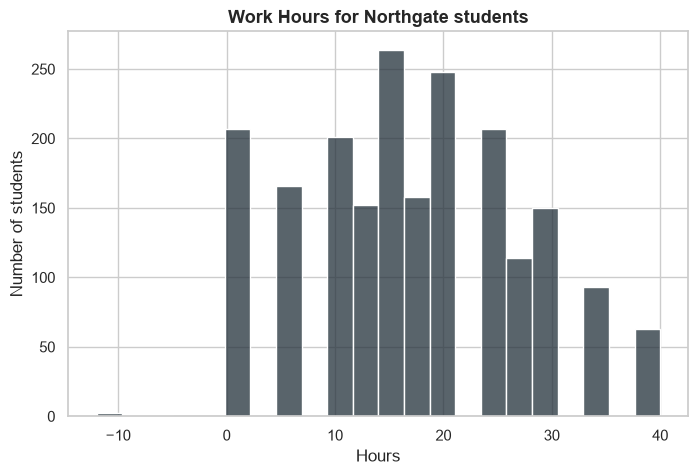

In [4]:
# Copy the closest cell from the Guided notebook, then fill in the blanks.

fig, ax = plt.subplots()
sns.histplot(data=students, x="work_hours_per_week", color=NAVY, ax=ax)
ax.set_title("Work Hours for Northgate students")
ax.set_xlabel("Hours")
ax.set_ylabel("Number of students")
plt.show()

# --- your code below ---


**STAR story — Q1** *(write in your own words)*

- **Scope —** what does this chart show? (which column(s), which students)

It shows the hours that the students at Northgate work a week. 
- **Track —** which question are you answering?

How many hours does an average student at northgate work. Also, what 
- **Articulate —** what does the chart actually say? (typical value, spread, shape, comparison, or trend)

I see that most of the chart is around the 10 to 20 hours. The median is around 20. There is a wide spread and a lot of people working 0 hours. 
- **Respond —** anything odd or unexpected? what would you look at next? *(note it — you don't fix it this week)*

There is a -10 number for hours worked per week which is impossible. Also no one works more than 40 hours which is also unlikely. I feel like some students could be working even 45 hours if they have to provide. 

### Q2 · One categorical variable
**How does enrollment compare across majors?**
→ *sorted bar chart*. Column: `major` (from `students`).

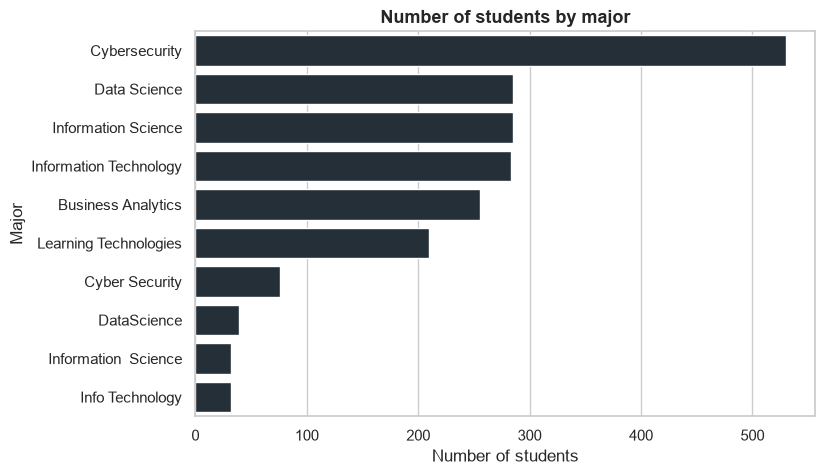

In [5]:
order = students["major"].value_counts().index          # sort by count
fig, ax = plt.subplots()
sns.countplot(data=students, y="major", order=order, color=NAVY, ax=ax)
ax.set_title("Number of students by major")
ax.set_xlabel("Number of students")
ax.set_ylabel("Major")
plt.show()



**STAR story — Q2** *(write in your own words)*

- **Scope —** what does this chart show? (which column(s), which students)

It shows the most popular majors by number of students at Northgate.
- **Track —** which question are you answering?

What is the most popular major? What is a major that has not that many people in it? What is the theme of the most popular majors? 
- **Articulate —** what does the chart actually say? (typical value, spread, shape, comparison, or trend)

Cybersecurirty is by far the most important major with more than 500 students from the survey enrolled in it. A lot of the majors are computer related. 
- **Respond —** anything odd or unexpected? what would you look at next? *(note it — you don't fix it this week)*

One of the fields is "Cybersecurity" while there is also a field thats "Cyber Security" with a space. This error happens when entering data is done by different people and not formatted correctly. Same thing with "Info Technology" and "Information Technology". These errors skew the data and make the graph look wrong. 

### Q3 · A quantity, split by category
**Does final GPA differ across majors?** Read the exceptions, not just the boxes.
→ *box plot per major*. Columns: `final_gpa` and `major` (from `students`).

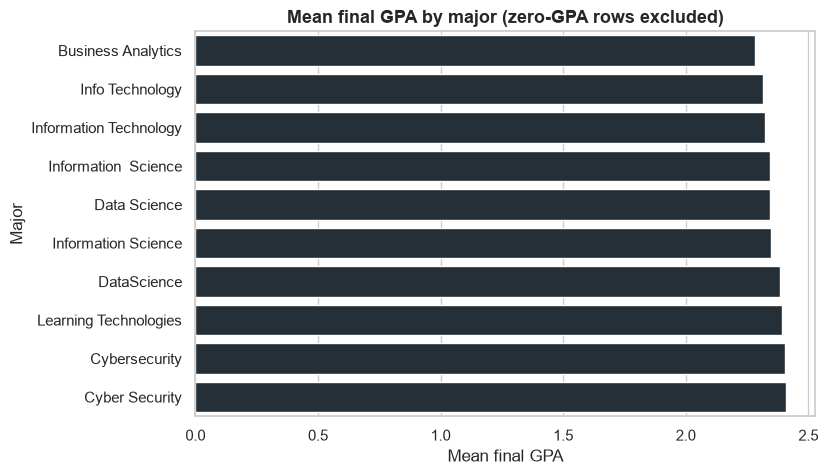

In [6]:
means = (students[students["final_gpa"] > 0]              # set zero-GPA rows aside
         .groupby("major")["final_gpa"].mean()
         .sort_values())
fig, ax = plt.subplots()
sns.barplot(x=means.values, y=means.index, color=NAVY, ax=ax)
ax.set_title("Mean final GPA by major (zero-GPA rows excluded)")
ax.set_xlabel("Mean final GPA")
ax.set_ylabel("Major")
plt.show()


**STAR story — Q3** *(write in your own words)*

- **Scope —** what does this chart show? (which column(s), which students)

It shows the students' GPA from various majors at Northgate. 
- **Track —** which question are you answering?

Which majors have the best final GPA and which ones have the worst at Norhtgate.
- **Articulate —** what does the chart actually say? (typical value, spread, shape, comparison, or trend)

Most of the final GPAs are around 2.4. All of the GPAs ar between 2 and 2.5 because the 0 GPA ones were ommitted. The shape is uniform and no major has a large difference in final GPA. However cybersecurity has the highest final GPA out of all of them.
- **Respond —** anything odd or unexpected? what would you look at next? *(note it — you don't fix it this week)*

There is a data inuput error on this one as well because "Cybersecurity" and "Cyber Security" are separate.

### Q4 · Two quantitative variables
**Is there a relationship between how far students commute and their final GPA?** Remember: *association is not causation.*
→ *scatterplot with a trend line*. Columns: `commute_miles` and `final_gpa` (from `students`).

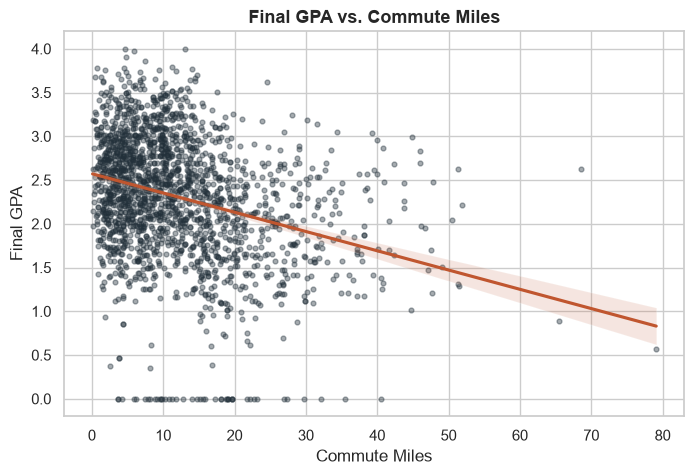

In [9]:
fig, ax = plt.subplots()
sns.regplot(data=students, x="commute_miles", y="final_gpa",
            scatter_kws={"s": 12, "color": NAVY, "alpha": 0.4},
            line_kws={"color": RUST}, ax=ax)
ax.set_title("Final GPA vs. Commute Miles")
ax.set_xlabel("Commute Miles")
ax.set_ylabel("Final GPA")
plt.show()

**STAR story — Q4** *(write in your own words)*

- **Scope —** what does this chart show? (which column(s), which students)

This graph shows the miles commuted and the final GPA of students that go to Northgate.
- **Track —** which question are you answering?

Does how far you have to drive affect the final GPA you will get? Will a student have a worse GPA beacuse they have to drive further
- **Articulate —** what does the chart actually say? (typical value, spread, shape, comparison, or trend)

Around 90% of the data is between 0 and 20 miles commute. This is typical of a normal college because most people do not want to drive very far. THere are a few outliers at 60-80 miles. There is a downward trend but it is not very strong. However, more pople that drive less, get a better final GPA.
- **Respond —** anything odd or unexpected? what would you look at next? *(note it — you don't fix it this week)*

One person had to drive around 80 miles which is unrealistic. 


### Q5 · Over time
**How does student engagement change across the semester?**
→ *line chart* of average weekly activity. Use the `weekly` table: `week` and `minutes_active` (you'll need to average by week first — see the Guided notebook).

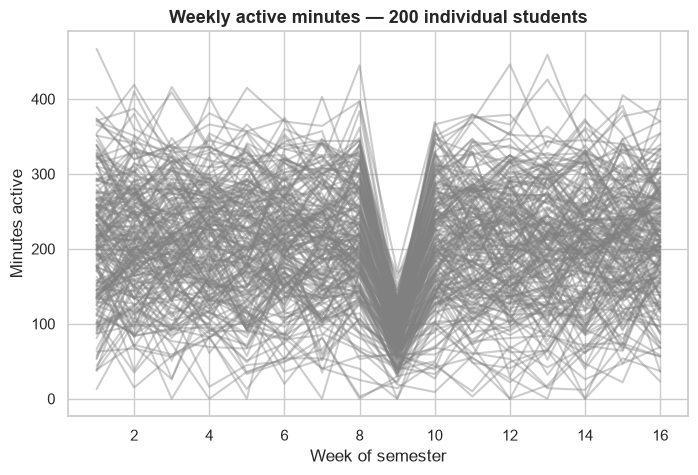

In [11]:
sample_ids = weekly["student_id"].drop_duplicates().sample(200, random_state=1)
sample = weekly[weekly["student_id"].isin(sample_ids)]
fig, ax = plt.subplots()
sns.lineplot(data=sample, x="week", y="minutes_active",
             units="student_id", estimator=None,
             color="grey", alpha=0.4, ax=ax)
ax.set_title("Weekly active minutes — 200 individual students")
ax.set_xlabel("Week of semester")
ax.set_ylabel("Minutes active")
plt.show()

**STAR story — Q5** *(write in your own words)*

- **Scope —** what does this chart show? (which column(s), which students)

It shows how many minutes per week are the students of Northgate active.
- **Track —** which question are you answering?

Are there any trends which we can see where the students are less active?
- **Articulate —** what does the chart actually say? (typical value, spread, shape, comparison, or trend)

There is no clear trend in most of the chart except around week 9 which is where the midterms are I am guessing. The weekly activity drops drastically in this period but goes back to normal after week 10. 
- **Respond —** anything odd or unexpected? what would you look at next? *(note it — you don't fix it this week)*

I am surprised that at week 16 there is no downtrend becasue it would be close to finals.

# Part B — Your own question (open)
Pose **one question of your own** about the Northgate students, choose the chart that answers it, build it, label it, and write its STAR story. Going beyond Part A is rewarded — a per-student line chart, a violin plot, or a chart of a messier column are all fair game.

**Your question:** How much do study hours affect the final GPA of the student?




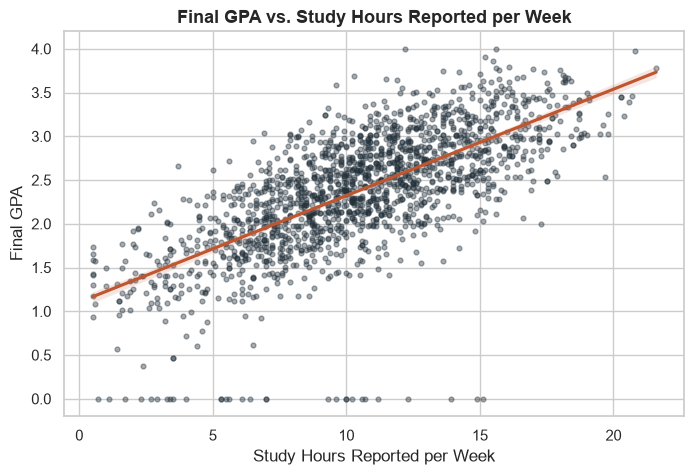

In [21]:
fig, ax = plt.subplots()
sns.regplot(data=students, x="study_hours_reported", y="final_gpa",
            scatter_kws={"s": 12, "color": NAVY, "alpha": 0.4},
            line_kws={"color": RUST}, ax=ax)
ax.set_title("Final GPA vs. Study Hours Reported per Week")
ax.set_xlabel("Study Hours Reported per Week")
ax.set_ylabel("Final GPA")
plt.show()

**STAR story — Part B** *(write in your own words)*

- **Scope —** what does this chart show? (which column(s), which students)

How many hours the students of Northgate study per week versus their final GPA.
- **Track —** which question are you answering?

What is the optimal amount of hours to study to pass on average. 
- **Articulate —** what does the chart actually say? (typical value, spread, shape, comparison, or trend)

As expected, there is a clear uptrend is the Final GPA based on the amount of hours studied per week. There is a large spread so some people can get as high as a 3.5 GPA on 10 hours of suding per week, which some need 20 hours just to get a 2.5 GPA. To actually graduate you need at least a 2.0 GPA in most places so, on average, you need around 10 hours of studying to secure that GPA and pass.
- **Respond —** anything odd or unexpected? what would you look at next? *(note it — you don't fix it this week)*

Actually nothing becasue this chart looks how I would expect it expect that some people got a 0 GPA even though they studied a lot.

# Before you submit — checklist
- [*] The notebook **runs top to bottom** with no errors (Runtime → Restart and run all).
- [*] All **6 charts** are present, each with a title, labeled axes, and units/legend where needed.
- [*] Each chart has a **complete STAR story**, including any exceptions you spotted.
- [*] Part B question is written in and answered.
- [*] Pushed to **GitHub**, and the **GitHub link** is submitted in Canvas.

**Rubric (70 pts):** chart choice 10 · correct build 20 · labeling 10 · STAR reading 18 · Part B question 4 · submission & professionalism 8.